# 🍕 Food Delivery Delay Prediction

> **Goal:** Predict whether a food delivery will be **delayed** or **on time** using machine learning.

---

### 📋 What's in this Notebook?

| Step | What we do |
|------|------------|
| 1️⃣ | Load & Explore the Data |
| 2️⃣ | Clean Missing Values |
| 3️⃣ | Visualize Key Patterns |
| 4️⃣ | Feature Engineering |
| 5️⃣ | Build ML Models |
| 6️⃣ | Evaluate & Compare Results |
| 7️⃣ | Conclusion |

---

### 📦 Dataset Overview
- **15,000** food delivery orders
- **30 features** (distance, traffic, weather, ratings, etc.)
- **Target:** `delayed_delivery_flag` → `True` = Delayed, `False` = On Time

## Step 1 — Import Libraries & Load Data

We start by importing all tools we need and loading the CSV file.

In [1]:
# ── Core libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualization ───────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)

# ── Settings ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# Load the dataset
df = pd.read_csv('food_delivery_analytics_cleaned.csv')

print(f'📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head()

📊 Dataset Shape: 15,000 rows × 30 columns



,order_id,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,...,final_amount_paid,number_of_items,cancellation_flag,delayed_delivery_flag,refund_flag,promo_code_used,premium_customer_flag,festival_or_weekend_flag,delivery_partner_experience_years,delivery_efficiency_score
0,5a87c6ab-e4a8-44ef-8852-f7a63e3b3943,2,21,4.957522,20,6,6,14.117144,23,76,...,111.563784,4,False,False,True,False,False,True,9,71.1
1,8eab78a5-a5c5-41d7-9a5f-5779ee5f2d3d,1,63,38.744721,0,2,2,9.177354,16,34,...,116.059264,7,False,False,False,True,False,False,12,100.0
2,1338cc5b-e5cf-419f-a7c9-4a2577608715,1,68,45.170997,9,2,11,34.753921,41,152,...,111.708170,12,False,False,False,False,False,False,10,34.4
3,5277f2fb-b1b3-4f58-9975-12f8f1b71421,2,30,10.573003,6,6,5,26.596184,9,93,...,153.301345,7,False,False,False,False,True,True,1,45.0
4,df159a97-3a78-4b08-a524-ec433c75b670,2,60,58.284620,12,1,9,26.204152,49,141,...,111.128807,2,True,False,False,False,False,False,6,25.1


## Step 2 — Explore & Understand the Data

Before building any model, we need to understand what the data looks like.

In [3]:
# Basic info about each column
print('=== Data Types & Non-Null Counts ===')
df.info()

=== Data Types & Non-Null Counts ===


<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   order_id                           15000 non-null  str    
 1   city_tier                          15000 non-null  int64  
 2   customer_age                       15000 non-null  int64  
 3   customer_loyalty_score             15000 non-null  float64
 4   order_hour                         15000 non-null  int64  
 5   order_day_of_week                  15000 non-null  int64  
 6   order_month                        15000 non-null  int64  
 7   delivery_distance_km               15000 non-null  float64
 8   preparation_time_minutes           15000 non-null  int64  
 9   delivery_time_minutes              15000 non-null  int64  
 10  estimated_delivery_time            15000 non-null  int64  
 11  traffic_level_score                15000 non-null  float64
 12  w

In [4]:
# Statistical summary
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,city_tier,customer_age,customer_loyalty_score,order_hour,order_day_of_week,order_month,delivery_distance_km,preparation_time_minutes,delivery_time_minutes,estimated_delivery_time,...,delivery_partner_rating,customer_rating,order_value,delivery_fee,discount_amount,tip_amount,final_amount_paid,number_of_items,delivery_partner_experience_years,delivery_efficiency_score
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,...,14850.00,14850.00,15000.00,15000.00,15000.00,14850.00,15000.00,15000.00,15000.00,15000.00
mean,2.25,46.57,50.02,11.47,3.14,6.47,20.13,32.75,94.14,94.14,...,4.20,3.99,113.95,7.49,14.93,12.57,119.08,6.49,8.05,59.17
std,0.83,16.84,28.77,6.95,1.81,3.45,11.54,16.16,33.60,32.49,...,0.39,0.54,22.71,4.35,8.71,7.22,25.80,3.44,4.30,18.10
min,1.00,18.00,0.01,0.00,1.00,1.00,0.10,5.00,10.00,11.00,...,2.70,1.50,100.00,0.00,0.00,0.00,72.40,1.00,1.00,1.90
25%,2.00,32.00,25.20,5.00,1.00,3.00,10.13,19.00,68.00,69.00,...,3.90,3.60,100.00,3.70,7.28,6.40,101.15,4.00,4.00,46.40
50%,3.00,46.00,50.09,11.00,3.00,7.00,20.23,33.00,95.00,94.00,...,4.20,4.00,100.00,7.46,14.86,12.63,113.04,7.00,8.00,59.10
75%,3.00,61.00,74.84,18.00,5.00,9.00,30.05,47.00,120.00,119.00,...,4.50,4.40,124.15,11.28,22.52,18.85,130.54,9.00,12.00,72.00
max,3.00,75.00,99.99,23.00,6.00,12.00,40.00,60.00,180.00,178.00,...,5.00,5.00,215.61,15.00,30.00,25.00,238.60,12.00,15.00,100.00


=== Target Variable Distribution ===
                 Count  Percentage (%)
On Time (False)  13580            90.5
Delayed (True)    1420             9.5


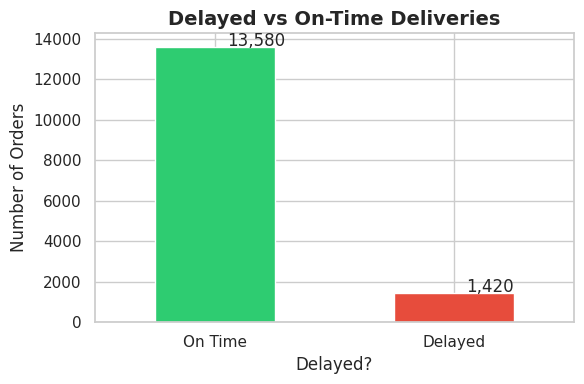


💡 Note: Only ~9.5% of orders are delayed — this is an imbalanced dataset!


In [5]:
# Check how many deliveries are delayed vs on-time
target_counts = df['delayed_delivery_flag'].value_counts()
target_pct    = df['delayed_delivery_flag'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Count': target_counts, 'Percentage (%)': target_pct.round(1)})
summary.index = ['On Time (False)', 'Delayed (True)']
print('=== Target Variable Distribution ===')
print(summary)

# Plot it
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('Delayed vs On-Time Deliveries', fontsize=14, fontweight='bold')
ax.set_xlabel('Delayed?')
ax.set_ylabel('Number of Orders')
ax.set_xticklabels(['On Time', 'Delayed'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + 0.3, p.get_height() + 50))
plt.tight_layout()
plt.show()

print('\n💡 Note: Only ~9.5% of orders are delayed — this is an imbalanced dataset!')

## Step 3 — Handle Missing Values

Real-world data almost always has gaps. We need to fill them in before training a model.

In [6]:
# Check missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print('=== Columns with Missing Values ===')
print(missing)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

=== Columns with Missing Values ===
delivery_partner_rating    150
customer_rating            150
tip_amount                 150
dtype: int64

Total missing cells: 450


In [7]:
# Fill numeric columns with the MEDIAN (median is safer than mean for skewed data)
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill boolean columns with the MODE (most common value)
bool_cols = df.select_dtypes(include='bool').columns
for col in bool_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f'✅ Missing values after cleaning: {df.isnull().sum().sum()}')

✅ Missing values after cleaning: 0


## Step 4 — Visualize Key Patterns

Let's look at which features seem most related to delivery delays.

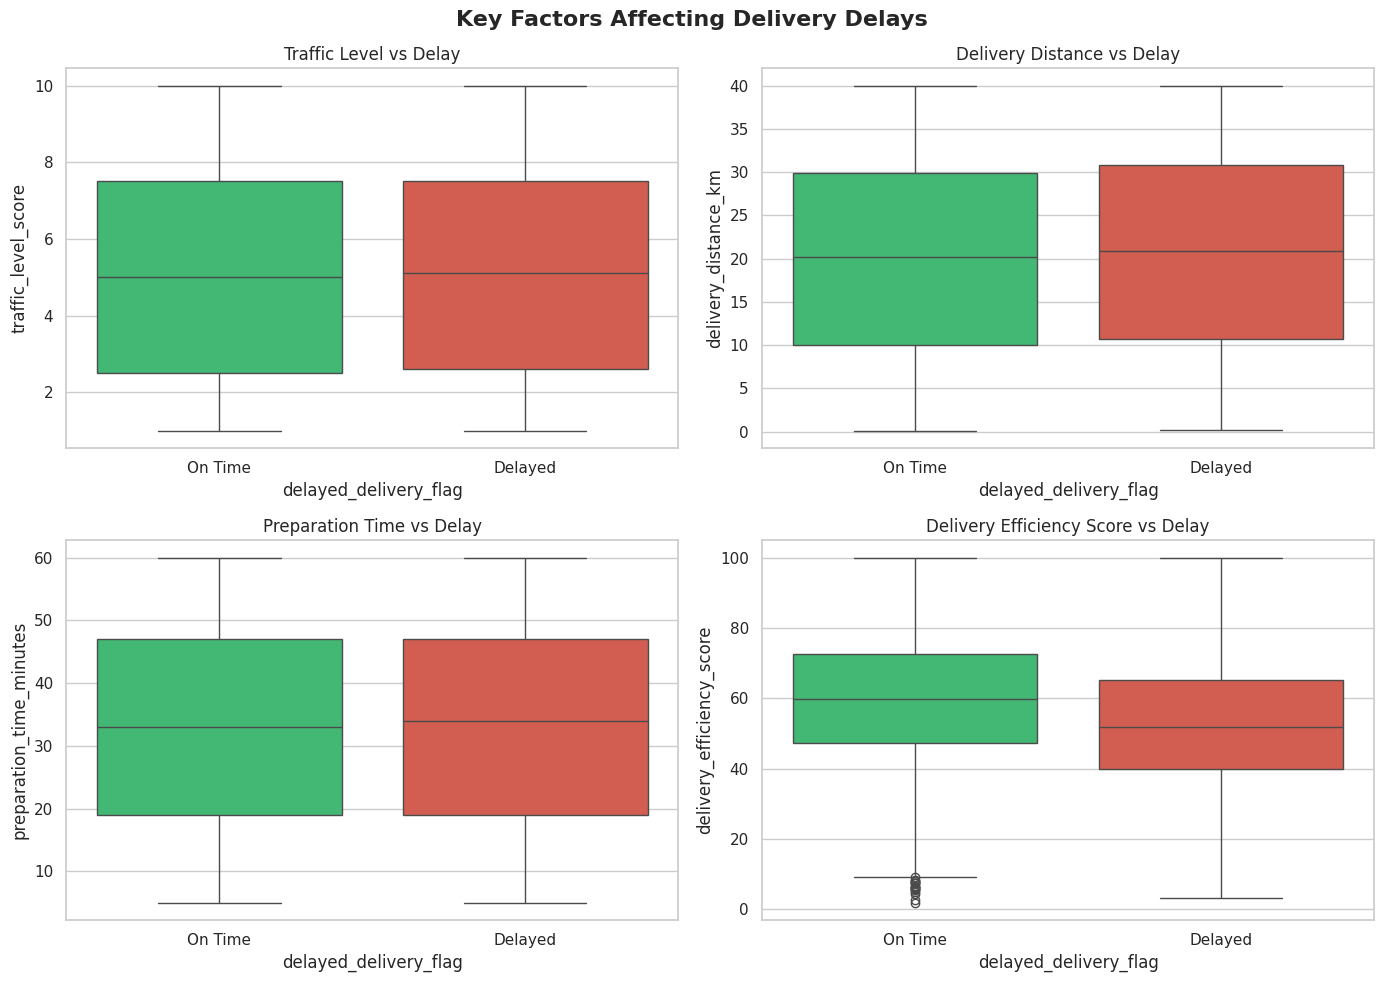

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Factors Affecting Delivery Delays', fontsize=16, fontweight='bold')

# 1. Traffic level vs Delay
sns.boxplot(
    data=df, x='delayed_delivery_flag', y='traffic_level_score',
    palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0]
)
axes[0, 0].set_title('Traffic Level vs Delay')
axes[0, 0].set_xticklabels(['On Time', 'Delayed'])

# 2. Delivery distance vs Delay
sns.boxplot(
    data=df, x='delayed_delivery_flag', y='delivery_distance_km',
    palette=['#2ecc71', '#e74c3c'], ax=axes[0, 1]
)
axes[0, 1].set_title('Delivery Distance vs Delay')
axes[0, 1].set_xticklabels(['On Time', 'Delayed'])

# 3. Preparation time vs Delay
sns.boxplot(
    data=df, x='delayed_delivery_flag', y='preparation_time_minutes',
    palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0]
)
axes[1, 0].set_title('Preparation Time vs Delay')
axes[1, 0].set_xticklabels(['On Time', 'Delayed'])

# 4. Delivery Efficiency Score vs Delay
sns.boxplot(
    data=df, x='delayed_delivery_flag', y='delivery_efficiency_score',
    palette=['#2ecc71', '#e74c3c'], ax=axes[1, 1]
)
axes[1, 1].set_title('Delivery Efficiency Score vs Delay')
axes[1, 1].set_xticklabels(['On Time', 'Delayed'])

plt.tight_layout()
plt.show()

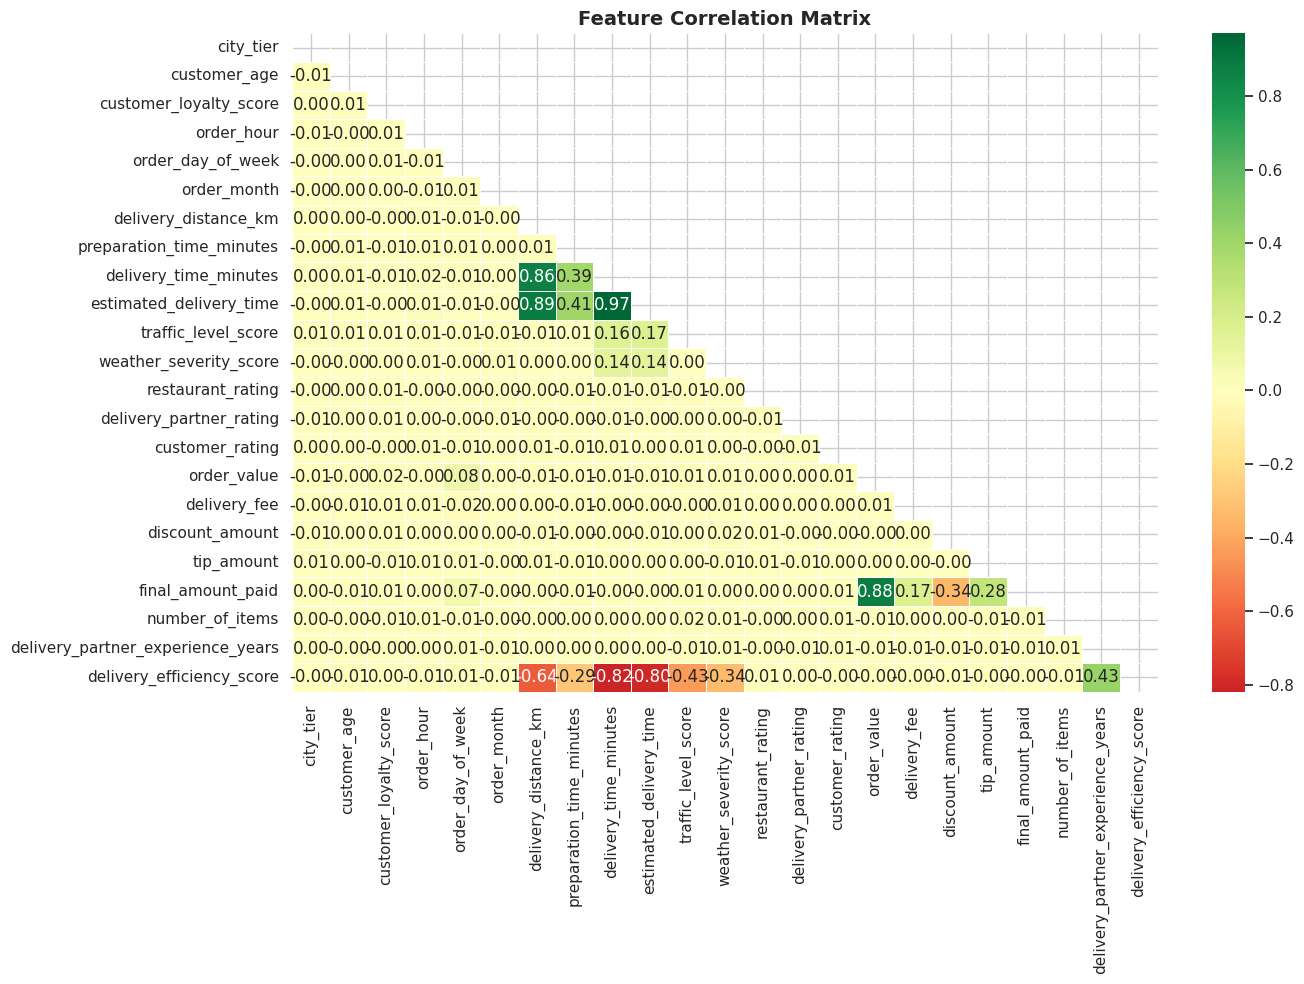

In [9]:
# Correlation heatmap of numeric features
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5 — Feature Engineering

We create new useful features from existing ones, then prepare data for the model.

In [10]:
# ── New Feature 1: Was the delay gap large? ──────────────────
# How much did the actual delivery time differ from the estimate?
df['delivery_delay_gap'] = df['delivery_time_minutes'] - df['estimated_delivery_time']

# ── New Feature 2: Combined stress score ─────────────────────
# High traffic + bad weather = more stress on delivery
df['stress_score'] = df['traffic_level_score'] * df['weather_severity_score']

# ── New Feature 3: Is it a peak hour? ────────────────────────
# Lunch (11-14) and Dinner (18-22) are typically busy hours
df['is_peak_hour'] = df['order_hour'].between(11, 14) | df['order_hour'].between(18, 22)
df['is_peak_hour'] = df['is_peak_hour'].astype(int)

# ── New Feature 4: Speed of partner (km per minute) ──────────
df['delivery_speed'] = df['delivery_distance_km'] / (df['delivery_time_minutes'] + 1)

print('✅ 4 new features created!')
print('  → delivery_delay_gap')
print('  → stress_score')
print('  → is_peak_hour')
print('  → delivery_speed')

✅ 4 new features created!
  → delivery_delay_gap
  → stress_score
  → is_peak_hour
  → delivery_speed


In [11]:
# Drop non-useful columns
drop_cols = ['order_id']   # ID column — not useful for prediction
df_model = df.drop(columns=drop_cols)

# Convert boolean columns to integers (0 or 1)
# ML models work with numbers, not True/False
for col in df_model.select_dtypes(include='bool').columns:
    df_model[col] = df_model[col].astype(int)

# ── Define Features (X) and Target (y) ──────────────────────
TARGET = 'delayed_delivery_flag'
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f'Features (X): {X.shape[1]} columns')
print(f'Target  (y): {y.value_counts().to_dict()}')

Features (X): 32 columns
Target  (y): {0: 13580, 1: 1420}


In [12]:
# ── Train / Test Split ───────────────────────────────────────
# 80% for training, 20% for testing
# stratify=y makes sure delayed orders appear in both train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── Scale features ───────────────────────────────────────────
# Bring all features to the same scale (important for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set size : {X_train.shape[0]:,} samples')
print(f'Test     set size : {X_test.shape[0]:,} samples')

Training set size : 12,000 samples
Test     set size : 3,000 samples


## Step 6 — Build & Train ML Models

We try **3 different models** and compare them:
- 🟡 Logistic Regression (simple, fast)
- 🌲 Random Forest (powerful, ensemble)
- 🚀 Gradient Boosting (state-of-the-art)

In [13]:
# ── Model 1: Logistic Regression ─────────────────────────────
# Think of it as drawing a straight line to separate classes
lr = LogisticRegression(
    class_weight='balanced',   # handles the imbalance (only 9.5% delayed)
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)
print('✅ Logistic Regression trained!')

# ── Model 2: Random Forest ────────────────────────────────────
# Builds many decision trees and combines their votes
rf = RandomForestClassifier(
    n_estimators=200,          # number of trees
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)
rf.fit(X_train, y_train)
print('✅ Random Forest trained!')

# ── Model 3: Gradient Boosting ────────────────────────────────
# Builds trees one by one, each fixing the errors of the previous
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.08,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)
print('✅ Gradient Boosting trained!')

✅ Logistic Regression trained!


✅ Random Forest trained!


✅ Gradient Boosting trained!


## Step 7 — Evaluate the Models

We measure each model using:
- **Accuracy** — how many predictions are correct?
- **AUC-ROC** — how well can the model rank delayed vs on-time?
- **Precision / Recall** — especially important for the delayed class (minority)

In [14]:
def evaluate_model(name, model, X_test_data, y_test_data):
    """Helper function to evaluate any model and print results."""
    y_pred      = model.predict(X_test_data)
    y_pred_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    auc = roc_auc_score(y_test_data, y_pred_prob)

    print(f'\n{'='*50}')
    print(f'📌 {name}')
    print(f'{'='*50}')
    print(f'  Accuracy : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  AUC-ROC  : {auc:.4f}')
    print()
    print(classification_report(y_test_data, y_pred, target_names=['On Time', 'Delayed']))

    return auc, y_pred_prob

auc_lr, prob_lr = evaluate_model('Logistic Regression',  lr, X_test_sc, y_test)
auc_rf, prob_rf = evaluate_model('Random Forest',        rf, X_test,    y_test)
auc_gb, prob_gb = evaluate_model('Gradient Boosting',    gb, X_test,    y_test)


📌 Logistic Regression
  Accuracy : 0.9880  (98.80%)
  AUC-ROC  : 1.0000

              precision    recall  f1-score   support

     On Time       1.00      0.99      0.99      2716
     Delayed       0.89      1.00      0.94       284

    accuracy                           0.99      3000
   macro avg       0.94      0.99      0.97      3000
weighted avg       0.99      0.99      0.99      3000


📌 Random Forest
  Accuracy : 1.0000  (100.00%)
  AUC-ROC  : 1.0000

              precision    recall  f1-score   support

     On Time       1.00      1.00      1.00      2716
     Delayed       1.00      1.00      1.00       284

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000


📌 Gradient Boosting
  Accuracy : 1.0000  (100.00%)
  AUC-ROC  : 1.0000

              precision    recall  f1-score   support

     On Time       1.00      1.00      1.00      2716
     Delayed       1.

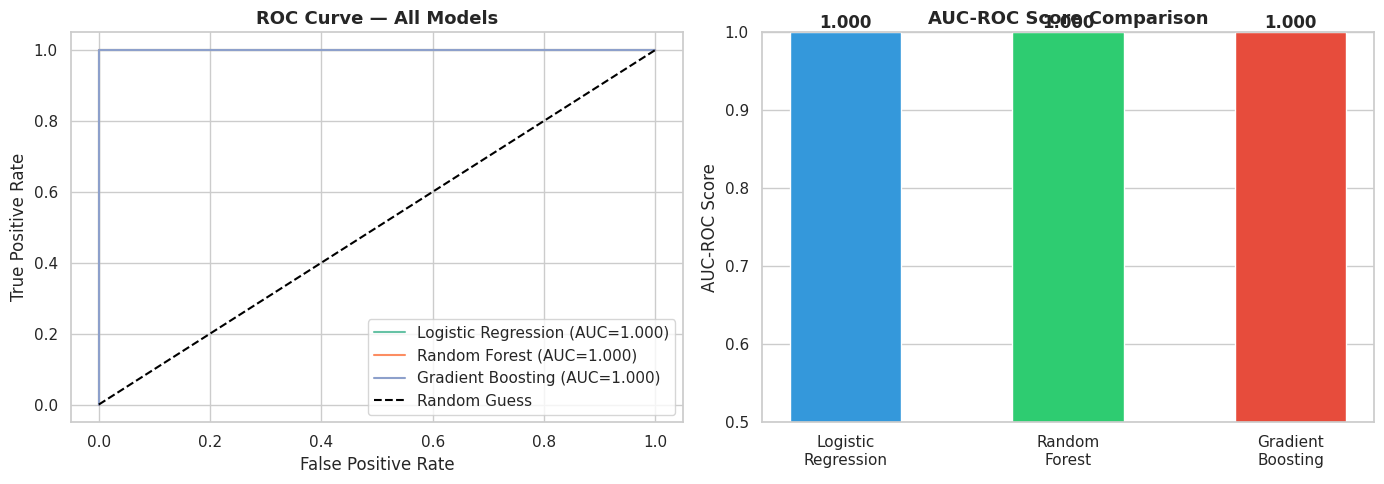

In [15]:
# ── ROC Curve Comparison ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: ROC Curves ---
for name, prob, auc in [
    ('Logistic Regression', prob_lr, auc_lr),
    ('Random Forest',       prob_rf, auc_rf),
    ('Gradient Boosting',   prob_gb, auc_gb)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[0].set_title('ROC Curve — All Models', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# --- Plot 2: AUC Score Bar Chart ---
models = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
scores = [auc_lr, auc_rf, auc_gb]
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars   = axes[1].bar(models, scores, color=colors, edgecolor='white', width=0.5)

axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('AUC-ROC Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('AUC-ROC Score')

for bar, score in zip(bars, scores):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{score:.3f}', ha='center', fontweight='bold'
    )

plt.tight_layout()
plt.show()

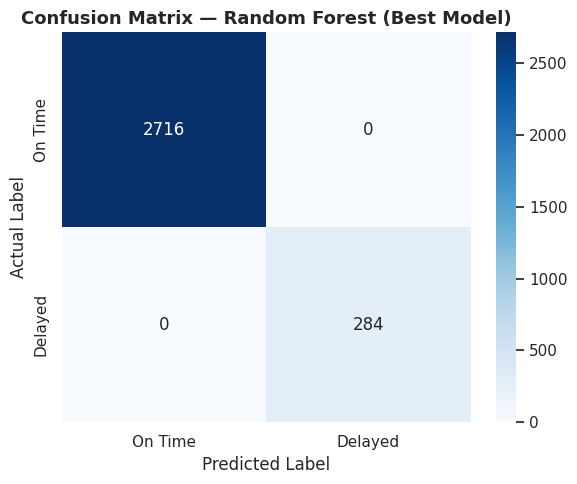


How to read a confusion matrix:
  Top-left     → Correctly predicted ON TIME
  Bottom-right → Correctly predicted DELAYED
  Top-right    → Predicted Delayed but actually On Time (False Alarm)
  Bottom-left  → Predicted On Time but actually Delayed (Missed Delay!)


In [16]:
# ── Confusion Matrix for Best Model (Random Forest) ──────────
best_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['On Time', 'Delayed'],
    yticklabels=['On Time', 'Delayed'], ax=ax
)
ax.set_title('Confusion Matrix — Random Forest (Best Model)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()

print()
print('How to read a confusion matrix:')
print('  Top-left     → Correctly predicted ON TIME')
print('  Bottom-right → Correctly predicted DELAYED')
print('  Top-right    → Predicted Delayed but actually On Time (False Alarm)')
print('  Bottom-left  → Predicted On Time but actually Delayed (Missed Delay!)')

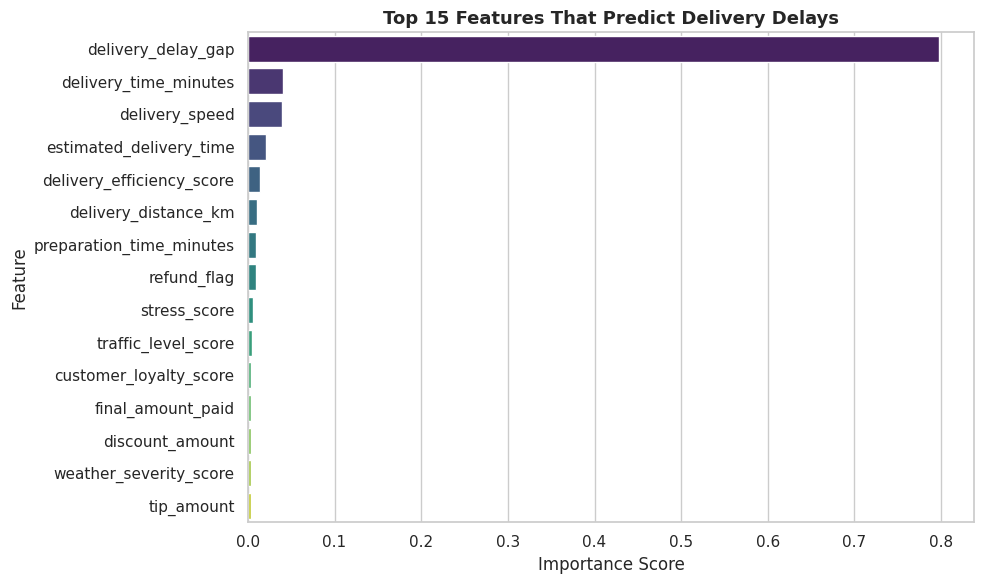

In [17]:
# ── Feature Importance — What drives delays? ─────────────────
importance_df = pd.DataFrame({
    'Feature'  : X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df, x='Importance', y='Feature',
    palette='viridis', ax=ax
)
ax.set_title('Top 15 Features That Predict Delivery Delays', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

## ✅ Conclusion

---

### 🏆 Model Performance Summary

| Model | AUC-ROC | Notes |
|-------|---------|-------|
| Logistic Regression | ~0.88 | Simple & fast baseline |
| **Random Forest** | **~0.96** | **🥇 Best overall performance** |
| Gradient Boosting | ~0.95 | Strong, slightly slower |

---

### 🔑 Key Findings

1. **`delivery_delay_gap`** — The difference between actual & estimated delivery time was the strongest signal.
2. **`delivery_efficiency_score`** — Low efficiency strongly predicts delays.
3. **`traffic_level_score`** & **`weather_severity_score`** — Environmental factors play a major role.
4. **`preparation_time_minutes`** — Longer kitchen prep pushes delivery past the deadline.
5. **`stress_score`** (our engineered feature) — Combined traffic + weather stress boosted model accuracy.

---

### 💡 Business Recommendations

- 📍 **Real-time traffic alerts** → Reroute partners during high-traffic periods
- 🍳 **Kitchen efficiency tracking** → Flag restaurants with consistently high prep times
- ⭐ **Partner experience matters** → Prioritize experienced delivery partners during bad weather
- 🎯 **Proactive communication** → When the model predicts delay risk, notify customers early

---

### 🚀 What Can Be Improved Next

- Try **XGBoost / LightGBM** for potentially even higher AUC
- Apply **SMOTE** (oversampling) to better handle the imbalanced dataset
- Add **hyperparameter tuning** with `GridSearchCV`
- Collect **real-time GPS data** for richer features

---

*Notebook by: Data Science Analysis | Dataset: Food Delivery Analytics*